# Tech Challenge - Fase 3: Análise Exploratória de Voos nos EUA

Este notebook cobre a etapa inicial do projeto, focada em **análise exploratória de dados (EDA)** da base pública de voos dos EUA.

Critérios atendidos nesta etapa:

- Estatísticas descritivas da base.
- Visualizações para geração de insights.
- Diagnóstico e tratamento adequado de valores ausentes.
- Criação de variáveis derivadas úteis para análises futuras.
- Uso do dicionário de dados para validar unidades, horários, status de voo e componentes operacionais.

As etapas de modelagem supervisionada e não supervisionada ficam para os próximos notebooks.

## 1. Preparação do ambiente

In [56]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Carregamento dos dados

O notebook procura os arquivos em alguns caminhos comuns. Para deixar o projeto mais portável, a recomendação é copiar as bases para uma pasta `data/` na raiz do repositório.

Arquivos esperados:

- `flights.csv`
- `airlines.csv`
- `airports.csv`

**Comentário:** esta célula localiza automaticamente os arquivos CSV, priorizando a pasta `data/` do projeto e usando `Downloads` como alternativa.

In [57]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

CANDIDATE_DIRS = [
    PROJECT_ROOT / "data",
    PROJECT_ROOT,
    Path.home() / "Downloads",
]

def find_file(filename: str) -> Path:
    for directory in CANDIDATE_DIRS:
        candidate = directory / filename
        if candidate.exists():
            return candidate
    searched = "\n".join(str(path / filename) for path in CANDIDATE_DIRS)
    raise FileNotFoundError(f"Arquivo {filename} não encontrado. Caminhos verificados:\n{searched}")

flights_path = find_file("flights.csv")
airlines_path = find_file("airlines.csv")
airports_path = find_file("airports.csv")

flights_path, airlines_path, airports_path

(PosixPath('/home/capizani/Downloads/flights.csv'),
 PosixPath('/home/capizani/Downloads/airlines.csv'),
 PosixPath('/home/capizani/Downloads/airports.csv'))

**Comentário:** a base de voos é grande; por isso os tipos de dados são definidos manualmente para reduzir uso de memória no carregamento.

In [58]:
dtype_flights = {
    "YEAR": "int16",
    "MONTH": "int8",
    "DAY": "int8",
    "DAY_OF_WEEK": "int8",
    "AIRLINE": "category",
    "FLIGHT_NUMBER": "int32",
    "TAIL_NUMBER": "category",
    "ORIGIN_AIRPORT": "category",
    "DESTINATION_AIRPORT": "category",
    "SCHEDULED_DEPARTURE": "float32",
    "DEPARTURE_TIME": "float32",
    "DEPARTURE_DELAY": "float32",
    "TAXI_OUT": "float32",
    "WHEELS_OFF": "float32",
    "SCHEDULED_TIME": "float32",
    "ELAPSED_TIME": "float32",
    "AIR_TIME": "float32",
    "DISTANCE": "float32",
    "WHEELS_ON": "float32",
    "TAXI_IN": "float32",
    "SCHEDULED_ARRIVAL": "float32",
    "ARRIVAL_TIME": "float32",
    "ARRIVAL_DELAY": "float32",
    "DIVERTED": "int8",
    "CANCELLED": "int8",
    "CANCELLATION_REASON": "category",
    "AIR_SYSTEM_DELAY": "float32",
    "SECURITY_DELAY": "float32",
    "AIRLINE_DELAY": "float32",
    "LATE_AIRCRAFT_DELAY": "float32",
    "WEATHER_DELAY": "float32",
}

flights = pd.read_csv(flights_path, dtype=dtype_flights)
airlines = pd.read_csv(airlines_path)
airports = pd.read_csv(airports_path)

print(f"Voos: {flights.shape[0]:,} linhas e {flights.shape[1]} colunas")
print(f"Companhias: {airlines.shape[0]:,} linhas")
print(f"Aeroportos: {airports.shape[0]:,} aeroportos")

Voos: 5,819,079 linhas e 31 colunas
Companhias: 14 linhas
Aeroportos: 322 aeroportos


**Comentário:** esta amostra inicial confirma se as três tabelas foram carregadas corretamente e permite verificar nomes e formatos das colunas.

In [59]:
display(flights.head())
display(airlines.head())
display(airports.head())

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5.00,2354.00,-11.00,21.00,15.00,205.00,194.00,169.00,1448.00,404.00,4.00,430.00,408.00,-22.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10.00,2.00,-8.00,12.00,14.00,280.00,279.00,263.00,2330.00,737.00,4.00,750.00,741.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20.00,18.00,-2.00,16.00,34.00,286.00,293.00,266.00,2296.00,800.00,11.00,806.00,811.00,5.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20.00,15.00,-5.00,15.00,30.00,285.00,281.00,258.00,2342.00,748.00,8.00,805.00,756.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25.00,24.00,-1.00,11.00,35.00,235.00,215.00,199.00,1448.00,254.00,5.00,320.00,259.00,-21.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65,-75.44
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41,-99.68
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04,-106.61
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.45,-98.42
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.54,-84.19


## 3. Visão geral da base

**Comentário:** este resumo mostra tipo, volume de nulos e quantidade de valores únicos por coluna, servindo como primeiro diagnóstico de qualidade dos dados.

In [60]:
overview = pd.DataFrame({
    "coluna": flights.columns,
    "tipo": flights.dtypes.astype(str).values,
    "nulos": flights.isna().sum().values,
    "perc_nulos": (flights.isna().mean().values * 100).round(2),
    "valores_unicos": flights.nunique(dropna=True).values,
})

overview.sort_values("perc_nulos", ascending=False)

,coluna,tipo,nulos,perc_nulos,valores_unicos
25,CANCELLATION_REASON,category,5729195,98.46,4
29,LATE_AIRCRAFT_DELAY,float32,4755640,81.72,695
30,WEATHER_DELAY,float32,4755640,81.72,632
28,AIRLINE_DELAY,float32,4755640,81.72,1067
26,AIR_SYSTEM_DELAY,float32,4755640,81.72,570
27,SECURITY_DELAY,float32,4755640,81.72,154
15,ELAPSED_TIME,float32,105071,1.81,712
16,AIR_TIME,float32,105071,1.81,675
22,ARRIVAL_DELAY,float32,105071,1.81,1240
18,WHEELS_ON,float32,92513,1.59,1440


## 3.1 Dicionário de dados aplicado

A análise abaixo organiza as colunas conforme o dicionário de dados anexado. Isso ajuda a separar campos de identificação, calendário, horários em formato `HHMM`, métricas operacionais em minutos, distância em milhas, status do voo e causas de atraso.

**Comentário:** o dicionário transforma as definições do PDF em uma tabela consultável dentro do notebook, facilitando a interpretação das próximas análises.

In [61]:
data_dictionary = pd.DataFrame([
    {"coluna": "YEAR", "grupo": "Calendário", "descricao": "Ano do voo", "tipo_unidade": "Inteiro"},
    {"coluna": "MONTH", "grupo": "Calendário", "descricao": "Mês do voo", "tipo_unidade": "Inteiro 1-12"},
    {"coluna": "DAY", "grupo": "Calendário", "descricao": "Dia do mês do voo", "tipo_unidade": "Inteiro 1-31"},
    {"coluna": "DAY_OF_WEEK", "grupo": "Calendário", "descricao": "Dia da semana", "tipo_unidade": "1=Segunda, 7=Domingo"},
    {"coluna": "AIRLINE", "grupo": "Identificação", "descricao": "Código da companhia aérea", "tipo_unidade": "Categórica"},
    {"coluna": "FLIGHT_NUMBER", "grupo": "Identificação", "descricao": "Número do voo", "tipo_unidade": "Inteiro"},
    {"coluna": "TAIL_NUMBER", "grupo": "Identificação", "descricao": "Registro da aeronave", "tipo_unidade": "Texto"},
    {"coluna": "ORIGIN_AIRPORT", "grupo": "Aeroporto/Rota", "descricao": "Código IATA do aeroporto de origem", "tipo_unidade": "Categórica"},
    {"coluna": "DESTINATION_AIRPORT", "grupo": "Aeroporto/Rota", "descricao": "Código IATA do aeroporto de destino", "tipo_unidade": "Categórica"},
    {"coluna": "SCHEDULED_DEPARTURE", "grupo": "Horário HHMM", "descricao": "Partida programada", "tipo_unidade": "HHMM"},
    {"coluna": "DEPARTURE_TIME", "grupo": "Horário HHMM", "descricao": "Partida real", "tipo_unidade": "HHMM"},
    {"coluna": "WHEELS_OFF", "grupo": "Horário HHMM", "descricao": "Decolagem", "tipo_unidade": "HHMM"},
    {"coluna": "WHEELS_ON", "grupo": "Horário HHMM", "descricao": "Pouso", "tipo_unidade": "HHMM"},
    {"coluna": "SCHEDULED_ARRIVAL", "grupo": "Horário HHMM", "descricao": "Chegada programada", "tipo_unidade": "HHMM"},
    {"coluna": "ARRIVAL_TIME", "grupo": "Horário HHMM", "descricao": "Chegada real", "tipo_unidade": "HHMM"},
    {"coluna": "DEPARTURE_DELAY", "grupo": "Atraso", "descricao": "Atraso na partida", "tipo_unidade": "Minutos"},
    {"coluna": "ARRIVAL_DELAY", "grupo": "Atraso", "descricao": "Atraso na chegada", "tipo_unidade": "Minutos"},
    {"coluna": "TAXI_OUT", "grupo": "Operacional", "descricao": "Taxiamento até decolagem", "tipo_unidade": "Minutos"},
    {"coluna": "SCHEDULED_TIME", "grupo": "Operacional", "descricao": "Tempo total programado", "tipo_unidade": "Minutos"},
    {"coluna": "ELAPSED_TIME", "grupo": "Operacional", "descricao": "Tempo total real", "tipo_unidade": "Minutos"},
    {"coluna": "AIR_TIME", "grupo": "Operacional", "descricao": "Tempo no ar", "tipo_unidade": "Minutos"},
    {"coluna": "TAXI_IN", "grupo": "Operacional", "descricao": "Taxiamento até portão", "tipo_unidade": "Minutos"},
    {"coluna": "DISTANCE", "grupo": "Rota", "descricao": "Distância entre origem e destino", "tipo_unidade": "Milhas"},
    {"coluna": "DIVERTED", "grupo": "Status", "descricao": "Voo desviado", "tipo_unidade": "1=sim, 0=não"},
    {"coluna": "CANCELLED", "grupo": "Status", "descricao": "Voo cancelado", "tipo_unidade": "1=sim, 0=não"},
    {"coluna": "CANCELLATION_REASON", "grupo": "Status", "descricao": "Motivo do cancelamento", "tipo_unidade": "A=Airline, B=Weather, C=NAS, D=Security"},
    {"coluna": "AIR_SYSTEM_DELAY", "grupo": "Causa de atraso", "descricao": "Atraso por sistema aéreo/controle de tráfego", "tipo_unidade": "Minutos"},
    {"coluna": "SECURITY_DELAY", "grupo": "Causa de atraso", "descricao": "Atraso por segurança", "tipo_unidade": "Minutos"},
    {"coluna": "AIRLINE_DELAY", "grupo": "Causa de atraso", "descricao": "Atraso atribuível à companhia", "tipo_unidade": "Minutos"},
    {"coluna": "LATE_AIRCRAFT_DELAY", "grupo": "Causa de atraso", "descricao": "Atraso por chegada tardia da aeronave", "tipo_unidade": "Minutos"},
    {"coluna": "WEATHER_DELAY", "grupo": "Causa de atraso", "descricao": "Atraso por clima", "tipo_unidade": "Minutos"},
])

data_dictionary

,coluna,grupo,descricao,tipo_unidade
0,YEAR,Calendário,Ano do voo,Inteiro
1,MONTH,Calendário,Mês do voo,Inteiro 1-12
2,DAY,Calendário,Dia do mês do voo,Inteiro 1-31
3,DAY_OF_WEEK,Calendário,Dia da semana,"1=Segunda, 7=Domingo"
4,AIRLINE,Identificação,Código da companhia aérea,Categórica
5,FLIGHT_NUMBER,Identificação,Número do voo,Inteiro
6,TAIL_NUMBER,Identificação,Registro da aeronave,Texto
7,ORIGIN_AIRPORT,Aeroporto/Rota,Código IATA do aeroporto de origem,Categórica
8,DESTINATION_AIRPORT,Aeroporto/Rota,Código IATA do aeroporto de destino,Categórica
9,SCHEDULED_DEPARTURE,Horário HHMM,Partida programada,HHMM


**Comentário:** aqui cruzamos o resumo da base com o dicionário para enxergar, em uma única tabela, significado, unidade, tipo e percentual de nulos de cada campo.

In [62]:
dictionary_coverage = overview.merge(data_dictionary, on="coluna", how="left")

display(
    dictionary_coverage[["coluna", "grupo", "descricao", "tipo_unidade", "tipo", "nulos", "perc_nulos", "valores_unicos"]]
    .sort_values(["grupo", "coluna"])
)

coverage_rate = dictionary_coverage["descricao"].notna().mean() * 100
print(f"Cobertura do dicionário sobre as colunas carregadas: {coverage_rate:.1f}%")

,coluna,grupo,descricao,tipo_unidade,tipo,nulos,perc_nulos,valores_unicos
8,DESTINATION_AIRPORT,Aeroporto/Rota,Código IATA do aeroporto de destino,Categórica,category,0,0.00,629
7,ORIGIN_AIRPORT,Aeroporto/Rota,Código IATA do aeroporto de origem,Categórica,category,0,0.00,628
22,ARRIVAL_DELAY,Atraso,Atraso na chegada,Minutos,float32,105071,1.81,1240
11,DEPARTURE_DELAY,Atraso,Atraso na partida,Minutos,float32,86153,1.48,1217
2,DAY,Calendário,Dia do mês do voo,Inteiro 1-31,int8,0,0.00,31
3,DAY_OF_WEEK,Calendário,Dia da semana,"1=Segunda, 7=Domingo",int8,0,0.00,7
1,MONTH,Calendário,Mês do voo,Inteiro 1-12,int8,0,0.00,12
0,YEAR,Calendário,Ano do voo,Inteiro,int16,0,0.00,1
28,AIRLINE_DELAY,Causa de atraso,Atraso atribuível à companhia,Minutos,float32,4755640,81.72,1067
26,AIR_SYSTEM_DELAY,Causa de atraso,Atraso por sistema aéreo/controle de tráfego,Minutos,float32,4755640,81.72,570


Cobertura do dicionário sobre as colunas carregadas: 100.0%


**Comentário:** as estatísticas descritivas ajudam a identificar escala, dispersão e valores extremos em atrasos, tempos operacionais e distância.

In [63]:
numeric_cols = flights.select_dtypes(include=["number"]).columns
flights[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,5819079.00,2015.00,0.00,2015.00,2015.00,2015.00,2015.00,2015.00
MONTH,5819079.00,6.52,3.41,1.00,4.00,7.00,9.00,12.00
DAY,5819079.00,15.70,8.78,1.00,8.00,16.00,23.00,31.00
DAY_OF_WEEK,5819079.00,3.93,1.99,1.00,2.00,4.00,6.00,7.00
FLIGHT_NUMBER,5819079.00,2173.09,1757.06,1.00,730.00,1690.00,3230.00,9855.00
SCHEDULED_DEPARTURE,5819079.00,1329.60,483.75,1.00,917.00,1325.00,1730.00,2359.00
DEPARTURE_TIME,5732926.00,1335.20,496.42,1.00,921.00,1330.00,1740.00,2400.00
DEPARTURE_DELAY,5732926.00,9.37,37.08,-82.00,-5.00,-2.00,7.00,1988.00
TAXI_OUT,5730032.00,16.07,8.90,1.00,11.00,14.00,19.00,225.00
WHEELS_OFF,5730032.00,1357.17,498.01,1.00,935.00,1343.00,1754.00,2400.00


**Comentário:** este resumo das variáveis categóricas mostra cardinalidade e categorias mais frequentes, útil para companhias, aeroportos, aeronaves e motivos de cancelamento.

In [64]:
categorical_cols = flights.select_dtypes(include=["category", "object"]).columns

cat_summary = []
for col in categorical_cols:
    value_counts = flights[col].value_counts(dropna=False).head(5)
    cat_summary.append({
        "coluna": col,
        "valores_unicos": flights[col].nunique(dropna=True),
        "top_5": value_counts.to_dict(),
    })

pd.DataFrame(cat_summary)

,coluna,valores_unicos,top_5
0,AIRLINE,14,"{'WN': 1261855, 'DL': 875881, 'AA': 725984, 'O..."
1,TAIL_NUMBER,4897,"{nan: 14721, 'N480HA': 3768, 'N484HA': 3723, '..."
2,ORIGIN_AIRPORT,628,"{'ATL': 346836, 'ORD': 285884, 'DFW': 239551, ..."
3,DESTINATION_AIRPORT,629,"{'ATL': 346904, 'ORD': 285906, 'DFW': 239582, ..."
4,CANCELLATION_REASON,4,"{nan: 5729195, 'B': 48851, 'A': 25262, 'C': 15..."


## 4. Enriquecimento e variáveis derivadas

Nesta etapa criamos variáveis que ajudam a responder perguntas do desafio, como atrasos por horário, dia da semana, companhia, aeroporto e rota.

**Comentário:** esta célula cria variáveis derivadas para facilitar a EDA, como data do voo, rota, período do dia e indicadores de atraso maior ou igual a 15 minutos.

In [65]:
def hhmm_to_minutes(value):
    if pd.isna(value):
        return np.nan
    value = int(value)
    hour = value // 100
    minute = value % 100
    if hour == 24:
        hour = 0
    if hour > 24 or minute > 59:
        return np.nan
    return hour * 60 + minute

def period_of_day(minutes):
    if pd.isna(minutes):
        return np.nan
    hour = int(minutes // 60)
    if 5 <= hour < 12:
        return "Manhã"
    if 12 <= hour < 18:
        return "Tarde"
    if 18 <= hour < 23:
        return "Noite"
    return "Madrugada"

weekday_map = {
    1: "Segunda",
    2: "Terça",
    3: "Quarta",
    4: "Quinta",
    5: "Sexta",
    6: "Sábado",
    7: "Domingo",
}

delay_reason_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY",
]

flights_eda = flights.copy()
flights_eda["FLIGHT_DATE"] = pd.to_datetime(flights_eda[["YEAR", "MONTH", "DAY"]])
flights_eda["DAY_OF_WEEK_NAME"] = flights_eda["DAY_OF_WEEK"].map(weekday_map)
flights_eda["ROUTE"] = flights_eda["ORIGIN_AIRPORT"].astype(str) + "-" + flights_eda["DESTINATION_AIRPORT"].astype(str)
flights_eda["SCHEDULED_DEPARTURE_MIN"] = flights_eda["SCHEDULED_DEPARTURE"].apply(hhmm_to_minutes).astype("float32")
flights_eda["DEPARTURE_PERIOD"] = flights_eda["SCHEDULED_DEPARTURE_MIN"].apply(period_of_day)
flights_eda["IS_DELAYED_ARRIVAL_15"] = (flights_eda["ARRIVAL_DELAY"] >= 15).astype("int8")
flights_eda["IS_DELAYED_DEPARTURE_15"] = (flights_eda["DEPARTURE_DELAY"] >= 15).astype("int8")

for col in delay_reason_cols:
    flights_eda[f"{col}_TREATED"] = flights_eda[col].fillna(0).astype("float32")

flights_eda["TAIL_NUMBER_TREATED"] = flights_eda["TAIL_NUMBER"].astype("object").fillna("UNKNOWN")

airlines_renamed = airlines.rename(columns={"IATA_CODE": "AIRLINE", "AIRLINE": "AIRLINE_NAME"})

airports_origin = airports.rename(columns={
    "IATA_CODE": "ORIGIN_AIRPORT",
    "AIRPORT": "ORIGIN_AIRPORT_NAME",
    "CITY": "ORIGIN_CITY",
    "STATE": "ORIGIN_STATE",
    "COUNTRY": "ORIGIN_COUNTRY",
    "LATITUDE": "ORIGIN_LATITUDE",
    "LONGITUDE": "ORIGIN_LONGITUDE",
})

airports_dest = airports.rename(columns={
    "IATA_CODE": "DESTINATION_AIRPORT",
    "AIRPORT": "DESTINATION_AIRPORT_NAME",
    "CITY": "DESTINATION_CITY",
    "STATE": "DESTINATION_STATE",
    "COUNTRY": "DESTINATION_COUNTRY",
    "LATITUDE": "DESTINATION_LATITUDE",
    "LONGITUDE": "DESTINATION_LONGITUDE",
})

flights_eda = flights_eda.merge(airlines_renamed, on="AIRLINE", how="left")
flights_eda = flights_eda.merge(airports_origin, on="ORIGIN_AIRPORT", how="left", validate="many_to_one")
flights_eda = flights_eda.merge(airports_dest, on="DESTINATION_AIRPORT", how="left", validate="many_to_one")

flights_eda.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FLIGHT_DATE,DAY_OF_WEEK_NAME,ROUTE,SCHEDULED_DEPARTURE_MIN,DEPARTURE_PERIOD,IS_DELAYED_ARRIVAL_15,IS_DELAYED_DEPARTURE_15,AIR_SYSTEM_DELAY_TREATED,SECURITY_DELAY_TREATED,AIRLINE_DELAY_TREATED,LATE_AIRCRAFT_DELAY_TREATED,WEATHER_DELAY_TREATED,TAIL_NUMBER_TREATED,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5.00,2354.00,-11.00,21.00,15.00,205.00,194.00,169.00,1448.00,404.00,4.00,430.00,408.00,-22.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,Quinta,ANC-SEA,5.00,Madrugada,0,0,0.00,0.00,0.00,0.00,0.00,N407AS,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17,-150.00,Seattle-Tacoma International Airport,Seattle,WA,USA,47.45,-122.31
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10.00,2.00,-8.00,12.00,14.00,280.00,279.00,263.00,2330.00,737.00,4.00,750.00,741.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,Quinta,LAX-PBI,10.00,Madrugada,0,0,0.00,0.00,0.00,0.00,0.00,N3KUAA,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94,-118.41,Palm Beach International Airport,West Palm Beach,FL,USA,26.68,-80.10
2,2015,1,1,4,US,840,N171US,SFO,CLT,20.00,18.00,-2.00,16.00,34.00,286.00,293.00,266.00,2296.00,800.00,11.00,806.00,811.00,5.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,Quinta,SFO-CLT,20.00,Madrugada,0,0,0.00,0.00,0.00,0.00,0.00,N171US,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.62,-122.37,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21,-80.94
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20.00,15.00,-5.00,15.00,30.00,285.00,281.00,258.00,2342.00,748.00,8.00,805.00,756.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,Quinta,LAX-MIA,20.00,Madrugada,0,0,0.00,0.00,0.00,0.00,0.00,N3HYAA,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94,-118.41,Miami International Airport,Miami,FL,USA,25.79,-80.29
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25.00,24.00,-1.00,11.00,35.00,235.00,215.00,199.00,1448.00,254.00,5.00,320.00,259.00,-21.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01,Quinta,SEA-ANC,25.00,Madrugada,0,0,0.00,0.00,0.00,0.00,0.00,N527AS,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.45,-122.31,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17,-150.00


## 4.1 Validações orientadas pelo dicionário

Como o dicionário define horários em `HHMM`, tempos em minutos e distância em milhas, vale checar consistência antes de interpretar os resultados. Essas validações ajudam a separar problemas reais de dados de diferenças esperadas por cancelamentos, desvios e virada de dia.

**Comentário:** esta validação separa valores ausentes de horários preenchidos em formato inválido. Horários programados tendem a existir sempre; horários reais podem faltar em cancelamentos e desvios.

In [66]:
hhmm_cols = [
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "SCHEDULED_ARRIVAL",
    "ARRIVAL_TIME",
]

# Horários programados tendem a estar preenchidos mesmo quando o voo é cancelado.
# Horários reais podem ficar ausentes em voos cancelados ou desviados.
status_series = np.select(
    [flights_eda["CANCELLED"].eq(1), flights_eda["DIVERTED"].eq(1)],
    ["Cancelado", "Desviado"],
    default="Concluído",
)

def validate_hhmm_series(series: pd.Series) -> pd.DataFrame:
    values = pd.to_numeric(series, errors="coerce")
    hours = values // 100
    minutes = values % 100
    filled_mask = values.notna()
    invalid_hour_mask = filled_mask & ~hours.between(0, 24)
    invalid_minute_mask = filled_mask & ~minutes.between(0, 59)
    invalid_2400_plus_mask = filled_mask & hours.eq(24) & minutes.ne(0)
    invalid_mask = invalid_hour_mask | invalid_minute_mask | invalid_2400_plus_mask

    return pd.DataFrame({
        "filled": filled_mask,
        "invalid_hour": invalid_hour_mask,
        "invalid_minute": invalid_minute_mask,
        "invalid_2400_plus": invalid_2400_plus_mask,
        "invalid": invalid_mask,
    })

hhmm_validation = []
for col in hhmm_cols:
    validation = validate_hhmm_series(flights_eda[col])
    filled_count = int(validation["filled"].sum())
    invalid_examples = flights_eda.loc[validation["invalid"], col].dropna().head(5).tolist()

    hhmm_validation.append({
        "coluna": col,
        "total_linhas": len(flights_eda),
        "ausentes": int(flights_eda[col].isna().sum()),
        "preenchidos": filled_count,
        "validos_hhmm": int((validation["filled"] & ~validation["invalid"]).sum()),
        "invalidos_hhmm": int(validation["invalid"].sum()),
        "invalidos_hora": int(validation["invalid_hour"].sum()),
        "invalidos_minuto": int(validation["invalid_minute"].sum()),
        "invalidos_24xx": int(validation["invalid_2400_plus"].sum()),
        "perc_ausentes": flights_eda[col].isna().mean() * 100,
        "perc_invalidos_sobre_preenchidos": validation["invalid"].sum() / max(filled_count, 1) * 100,
        "min_preenchido": flights_eda[col].min(),
        "max_preenchido": flights_eda[col].max(),
        "exemplos_invalidos": invalid_examples,
    })

hhmm_validation = pd.DataFrame(hhmm_validation)
hhmm_validation

,coluna,total_linhas,ausentes,preenchidos,validos_hhmm,invalidos_hhmm,invalidos_hora,invalidos_minuto,invalidos_24xx,perc_ausentes,perc_invalidos_sobre_preenchidos,min_preenchido,max_preenchido,exemplos_invalidos
0,SCHEDULED_DEPARTURE,5819079,0,5819079,5819079,0,0,0,0,0.00,0.00,1.00,2359.00,[]
1,DEPARTURE_TIME,5819079,86153,5732926,5732926,0,0,0,0,1.48,0.00,1.00,2400.00,[]
2,WHEELS_OFF,5819079,89047,5730032,5730032,0,0,0,0,1.53,0.00,1.00,2400.00,[]
3,WHEELS_ON,5819079,92513,5726566,5726566,0,0,0,0,1.59,0.00,1.00,2400.00,[]
4,SCHEDULED_ARRIVAL,5819079,0,5819079,5819079,0,0,0,0,0.00,0.00,1.00,2400.00,[]
5,ARRIVAL_TIME,5819079,92513,5726566,5726566,0,0,0,0,1.59,0.00,1.00,2400.00,[]


**Comentário:** esta tabela mostra o percentual de preenchimento dos horários por status do voo. Ela explica por que horários reais têm mais nulos em voos cancelados ou desviados.

In [67]:
# Percentual de preenchimento de cada horário por status do voo.
# Ex.: 4.15 em DEPARTURE_TIME para voos cancelados significa que só 4,15% dos voos cancelados têm partida real registrada.
percentual_preenchimento_horarios_por_status = (
    flights_eda.assign(STATUS=status_series)
    .groupby("STATUS")[hhmm_cols]
    .apply(lambda df: df.notna().mean().mul(100).round(2))
)

percentual_preenchimento_horarios_por_status

,SCHEDULED_DEPARTURE,DEPARTURE_TIME,WHEELS_OFF,WHEELS_ON,SCHEDULED_ARRIVAL,ARRIVAL_TIME
STATUS,,,,,,
Cancelado,100.00,4.15,0.93,0.00,100.00,0.00
Concluído,100.00,100.00,100.00,100.00,100.00,100.00
Desviado,100.00,100.00,100.00,82.69,100.00,82.69


**Comentário:** esta é uma checagem de consistência matemática. Valores próximos de zero indicam que os tempos operacionais e os atrasos são coerentes entre si.

In [68]:
completed_flights_check = flights_eda.query("CANCELLED == 0 and DIVERTED == 0").copy()
completed_flights_check["ELAPSED_COMPONENT_DIFF"] = (
    completed_flights_check["ELAPSED_TIME"]
    - completed_flights_check["AIR_TIME"]
    - completed_flights_check["TAXI_OUT"]
    - completed_flights_check["TAXI_IN"]
)
completed_flights_check["ARRIVAL_DELAY_RECONCILIATION"] = (
    completed_flights_check["ARRIVAL_DELAY"]
    - completed_flights_check["DEPARTURE_DELAY"]
    - (completed_flights_check["ELAPSED_TIME"] - completed_flights_check["SCHEDULED_TIME"])
)

consistency_summary = completed_flights_check[[
    "ELAPSED_COMPONENT_DIFF",
    "ARRIVAL_DELAY_RECONCILIATION",
]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

consistency_summary

,count,mean,std,min,1%,5%,50%,95%,99%,max
ELAPSED_COMPONENT_DIFF,5714008.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ARRIVAL_DELAY_RECONCILIATION,5714008.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00


## 5. Tratamento de valores ausentes

Nem todo valor ausente representa erro. Nesta base, muitos nulos são consequência do ciclo operacional do voo:

- Voos cancelados não possuem horários reais de partida, chegada e duração.
- Voos desviados podem não ter atraso final comparável ao destino original.
- Colunas de causa de atraso aparecem nulas quando não houve atraso relevante registrado.
- `TAIL_NUMBER` ausente indica falta de identificação da aeronave, não necessariamente ausência do voo.

Estratégia adotada para EDA:

- Preservar flags `CANCELLED` e `DIVERTED` para análises próprias.
- Excluir cancelados/desviados em análises de atraso de chegada.
- Tratar causas de atraso nulas como `0` quando a análise for sobre composição de atrasos.
- Preencher identificação ausente de aeronave com `UNKNOWN` apenas em variável derivada.

**Comentário:** esta tabela mostra como os nulos variam por status do voo. Isso evita tratar como erro um valor ausente que é consequência natural de cancelamento ou desvio.

In [69]:
missing_by_status = flights.assign(
    STATUS=np.select(
        [flights["CANCELLED"].eq(1), flights["DIVERTED"].eq(1)],
        ["Cancelado", "Desviado"],
        default="Concluído",
    )
).groupby("STATUS")[[
    "DEPARTURE_TIME",
    "DEPARTURE_DELAY",
    "ARRIVAL_TIME",
    "ARRIVAL_DELAY",
    "AIR_TIME",
    "CANCELLATION_REASON",
]].apply(lambda df: df.isna().mean().mul(100).round(2))

missing_by_status

,DEPARTURE_TIME,DEPARTURE_DELAY,ARRIVAL_TIME,ARRIVAL_DELAY,AIR_TIME,CANCELLATION_REASON
STATUS,,,,,,
Cancelado,95.85,95.85,100.00,100.00,100.00,0.00
Concluído,0.00,0.00,0.00,0.00,0.00,100.00
Desviado,0.00,0.00,17.31,100.00,100.00,100.00


**Comentário:** a análise de atraso de chegada usa apenas voos concluídos, pois voos cancelados ou desviados não têm chegada comparável ao destino original.

In [70]:
completed_flights = flights_eda.query("CANCELLED == 0 and DIVERTED == 0").copy()
delayed_arrivals = completed_flights.query("ARRIVAL_DELAY >= 15").copy()

print(f"Voos concluídos: {len(completed_flights):,}")
print(f"Voos com atraso de chegada >= 15 min: {len(delayed_arrivals):,}")
print(f"Taxa de atraso de chegada >= 15 min: {completed_flights['IS_DELAYED_ARRIVAL_15'].mean() * 100:.2f}%")

Voos concluídos: 5,714,008
Voos com atraso de chegada >= 15 min: 1,063,439
Taxa de atraso de chegada >= 15 min: 18.61%


## 6. Distribuição geral de atrasos

**Comentário:** este resumo compara atraso de partida e chegada, incluindo percentis para observar a cauda dos atrasos sem depender apenas da média.

In [71]:
delay_summary = completed_flights[["DEPARTURE_DELAY", "ARRIVAL_DELAY"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
delay_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
DEPARTURE_DELAY,5714008.00,9.29,36.89,-82.00,-13.00,-9.00,-5.00,-2.00,7.00,67.00,167.00,1988.00
ARRIVAL_DELAY,5714008.00,4.41,39.27,-87.00,-34.00,-25.00,-13.00,-5.00,8.00,66.00,167.00,1971.00


**Comentário:** o histograma usa uma faixa limitada para visualizar melhor a distribuição principal, sem deixar atrasos extremos comprimirem o gráfico.

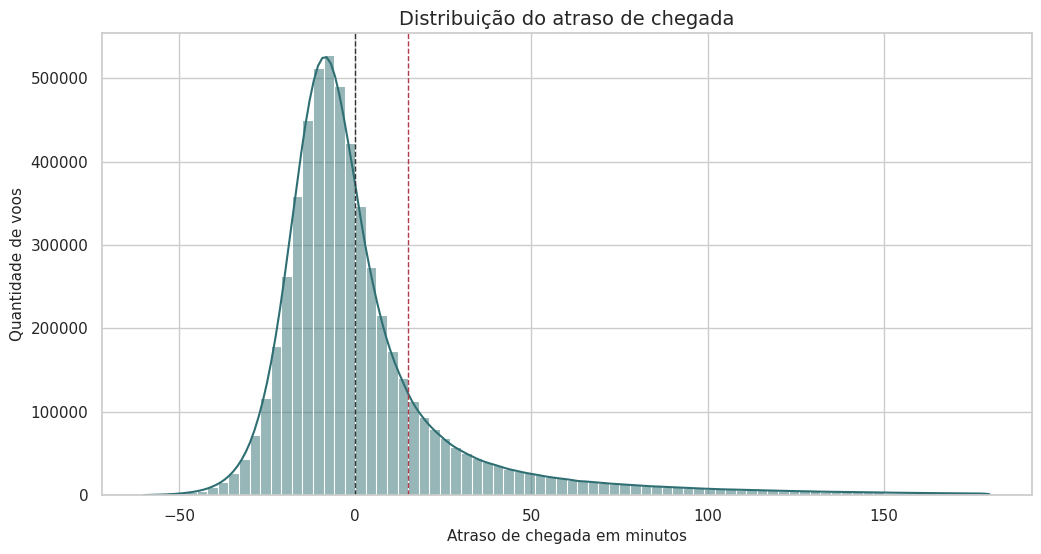

In [72]:
plot_data = completed_flights.query("ARRIVAL_DELAY >= -60 and ARRIVAL_DELAY <= 180")

sns.histplot(data=plot_data, x="ARRIVAL_DELAY", bins=80, kde=True, color="#2f6f73")
plt.axvline(0, color="#333333", linestyle="--", linewidth=1)
plt.axvline(15, color="#b23a48", linestyle="--", linewidth=1)
plt.title("Distribuição do atraso de chegada")
plt.xlabel("Atraso de chegada em minutos")
plt.ylabel("Quantidade de voos")
plt.show()

**Comentário:** este gráfico mostra a relação entre atraso de partida e atraso de chegada, ajudando a ver se voos recuperam ou ampliam atraso durante a operação.

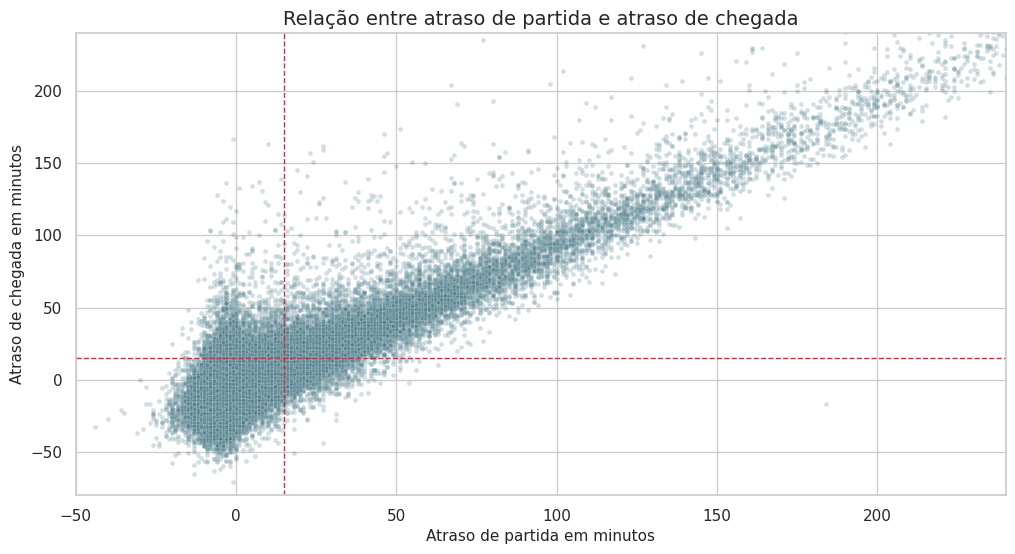

In [73]:
sns.scatterplot(
    data=completed_flights.sample(min(100_000, len(completed_flights)), random_state=42),
    x="DEPARTURE_DELAY",
    y="ARRIVAL_DELAY",
    alpha=0.25,
    s=12,
    color="#4d7c8a",
)
plt.axhline(15, color="#b23a48", linestyle="--", linewidth=1)
plt.axvline(15, color="#b23a48", linestyle="--", linewidth=1)
plt.xlim(-50, 240)
plt.ylim(-80, 240)
plt.title("Relação entre atraso de partida e atraso de chegada")
plt.xlabel("Atraso de partida em minutos")
plt.ylabel("Atraso de chegada em minutos")
plt.show()

## 6.1 Componentes operacionais do voo

O dicionário separa o tempo total real (`ELAPSED_TIME`) em taxiamento de saída, tempo no ar e taxiamento de chegada. Essa abertura ajuda a investigar se atrasos estão mais associados a operação em solo, rota aérea ou propagação do atraso de partida.

**Comentário:** estas estatísticas descrevem os componentes operacionais do voo, como taxiamento, tempo no ar, tempo total e distância.

In [74]:
operational_cols = ["TAXI_OUT", "AIR_TIME", "TAXI_IN", "SCHEDULED_TIME", "ELAPSED_TIME", "DISTANCE"]
completed_flights[operational_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
TAXI_OUT,5714008.00,16.07,8.88,1.00,6.00,8.00,14.00,31.00,50.00,225.00
AIR_TIME,5714008.00,113.51,72.23,7.00,23.00,34.00,94.00,273.00,337.00,690.00
TAXI_IN,5714008.00,7.43,5.62,1.00,2.00,3.00,6.00,16.00,30.00,248.00
SCHEDULED_TIME,5714008.00,141.89,75.31,18.00,44.00,59.00,123.00,309.00,377.00,718.00
ELAPSED_TIME,5714008.00,137.01,74.21,14.00,41.00,54.00,118.00,299.00,367.00,766.00
DISTANCE,5714008.00,824.46,608.66,31.00,100.00,173.00,650.00,2239.00,2588.00,4983.00


**Comentário:** esta análise usa o p95 do taxiamento de saída para identificar aeroportos onde uma parcela relevante dos voos enfrenta espera longa em solo.

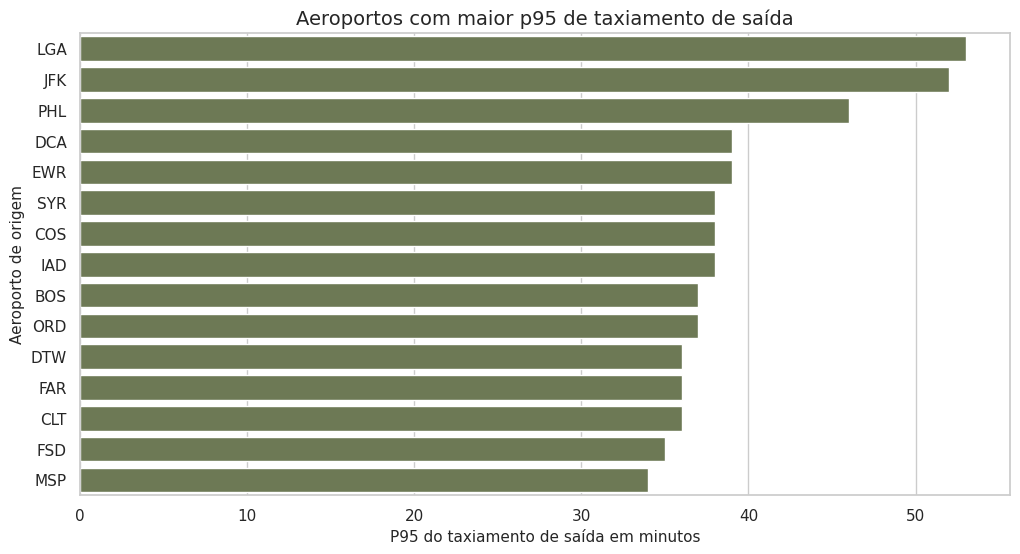

,ORIGIN_AIRPORT,ORIGIN_CITY,ORIGIN_STATE,total_voos,taxi_out_medio,taxi_out_p95,taxa_atraso_15
182,LGA,New York,NY,94834,26.71,53.00,23.95
166,JFK,New York,NY,91663,27.00,52.00,22.10
238,PHL,Philadelphia,PA,64751,21.69,46.00,21.89
84,DCA,Arlington,VA,71579,18.78,39.00,18.27
106,EWR,Newark,NJ,98341,20.18,39.00,21.52
300,SYR,Syracuse,NY,5447,16.49,38.00,16.71
72,COS,Colorado Springs,CO,6745,19.19,38.00,18.53
149,IAD,Chantilly,VA,33664,17.46,38.00,20.83
39,BOS,Boston,MA,104804,20.01,37.00,20.38
228,ORD,Chicago,IL,276554,19.53,37.00,24.10


In [75]:
taxi_airport = completed_flights.groupby(["ORIGIN_AIRPORT", "ORIGIN_CITY", "ORIGIN_STATE"], observed=True).agg(
    total_voos=("TAXI_OUT", "size"),
    taxi_out_medio=("TAXI_OUT", "mean"),
    taxi_out_p95=("TAXI_OUT", lambda s: s.quantile(0.95)),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reset_index()
taxi_airport["taxa_atraso_15"] *= 100

taxi_airport_filtered = taxi_airport.query("total_voos >= 5000").sort_values("taxi_out_p95", ascending=False)

sns.barplot(data=taxi_airport_filtered.head(15), y="ORIGIN_AIRPORT", x="taxi_out_p95", color="#6f7f4f")
plt.title("Aeroportos com maior p95 de taxiamento de saída")
plt.xlabel("P95 do taxiamento de saída em minutos")
plt.ylabel("Aeroporto de origem")
plt.show()

taxi_airport_filtered.head(15)

**Comentário:** a matriz de correlação ajuda a identificar relações lineares entre atrasos, distância e tempos operacionais. Ela não prova causalidade, mas orienta hipóteses.

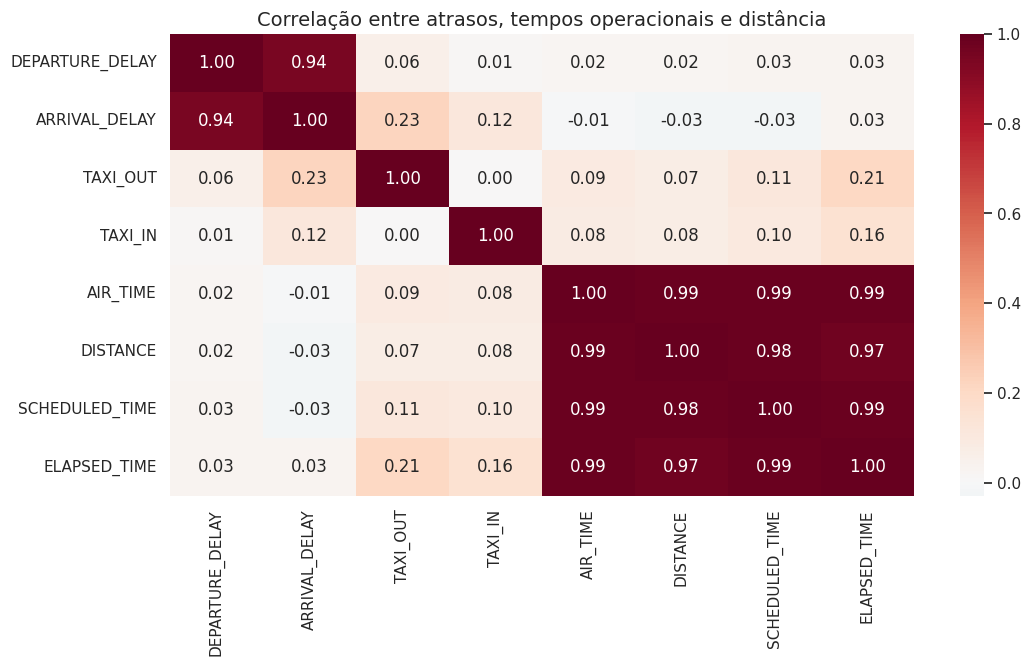

In [76]:
corr_cols = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "TAXI_OUT",
    "TAXI_IN",
    "AIR_TIME",
    "DISTANCE",
    "SCHEDULED_TIME",
    "ELAPSED_TIME",
]

corr = completed_flights[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlação entre atrasos, tempos operacionais e distância")
plt.show()

## 7. Padrões temporais

**Comentário:** esta agregação mostra se a taxa de atrasos muda ao longo dos meses, capturando possíveis padrões sazonais.

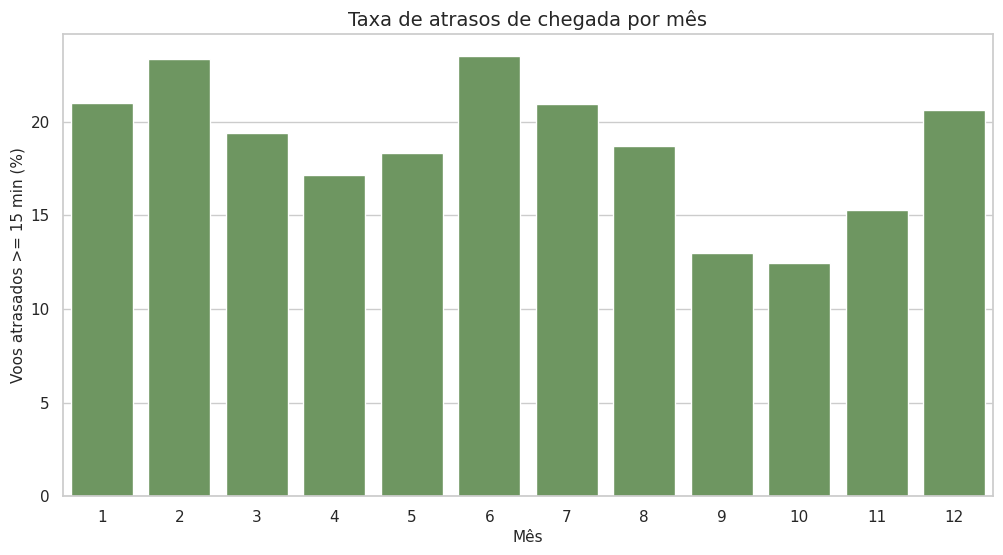

,MONTH,total_voos,atraso_medio_chegada,taxa_atraso_15
0,1,457013,5.81,21.00
1,2,407663,8.32,23.35
2,3,492138,4.92,19.40
3,4,479251,3.16,17.16
4,5,489641,4.49,18.31
5,6,492847,9.60,23.48
6,7,514384,6.43,20.92
7,8,503956,4.61,18.67
8,9,462153,-0.77,13.00
9,10,482878,-0.78,12.44


In [77]:
monthly_delay = completed_flights.groupby("MONTH").agg(
    total_voos=("ARRIVAL_DELAY", "size"),
    atraso_medio_chegada=("ARRIVAL_DELAY", "mean"),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reset_index()
monthly_delay["taxa_atraso_15"] *= 100

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=monthly_delay, x="MONTH", y="taxa_atraso_15", color="#6a9f58", ax=ax1)
ax1.set_title("Taxa de atrasos de chegada por mês")
ax1.set_xlabel("Mês")
ax1.set_ylabel("Voos atrasados >= 15 min (%)")
plt.show()

monthly_delay

**Comentário:** esta análise compara dias da semana para verificar se atrasos se concentram em dias de maior demanda operacional.

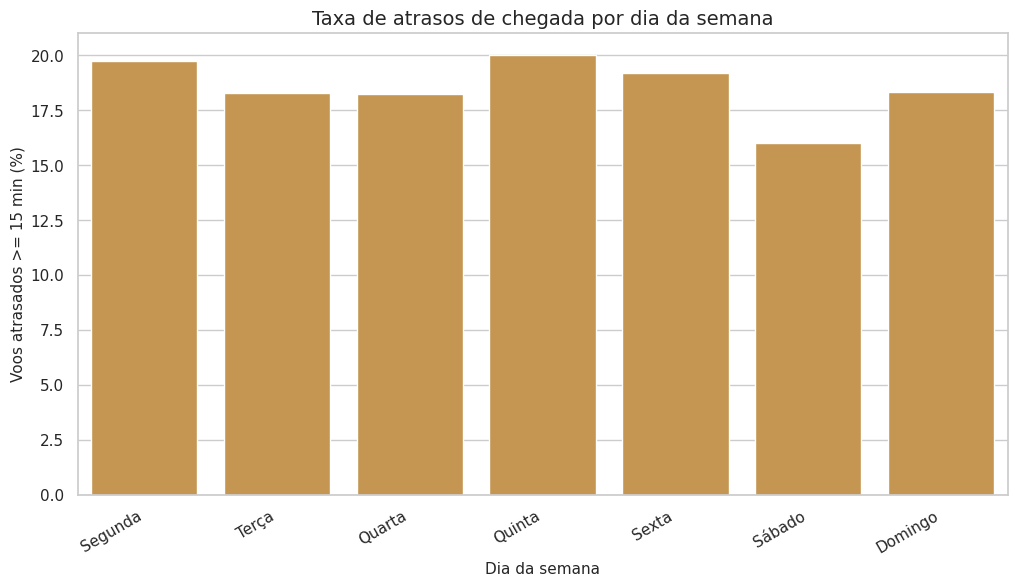

,DAY_OF_WEEK_NAME,total_voos,atraso_medio_chegada,taxa_atraso_15
0,Segunda,841794,6.00,19.75
1,Terça,827399,4.25,18.27
2,Quarta,843242,3.85,18.22
3,Quinta,857886,5.67,20.01
4,Sexta,851387,4.76,19.20
5,Sábado,689745,1.85,15.99
6,Domingo,802555,3.96,18.31


In [78]:
weekday_order = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]

weekday_delay = completed_flights.groupby("DAY_OF_WEEK_NAME").agg(
    total_voos=("ARRIVAL_DELAY", "size"),
    atraso_medio_chegada=("ARRIVAL_DELAY", "mean"),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reindex(weekday_order).reset_index()
weekday_delay["taxa_atraso_15"] *= 100

sns.barplot(data=weekday_delay, x="DAY_OF_WEEK_NAME", y="taxa_atraso_15", color="#d99a3d")
plt.title("Taxa de atrasos de chegada por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Voos atrasados >= 15 min (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

weekday_delay

**Comentário:** esta visão por período do dia ajuda a observar acúmulo de atrasos ao longo da jornada operacional.

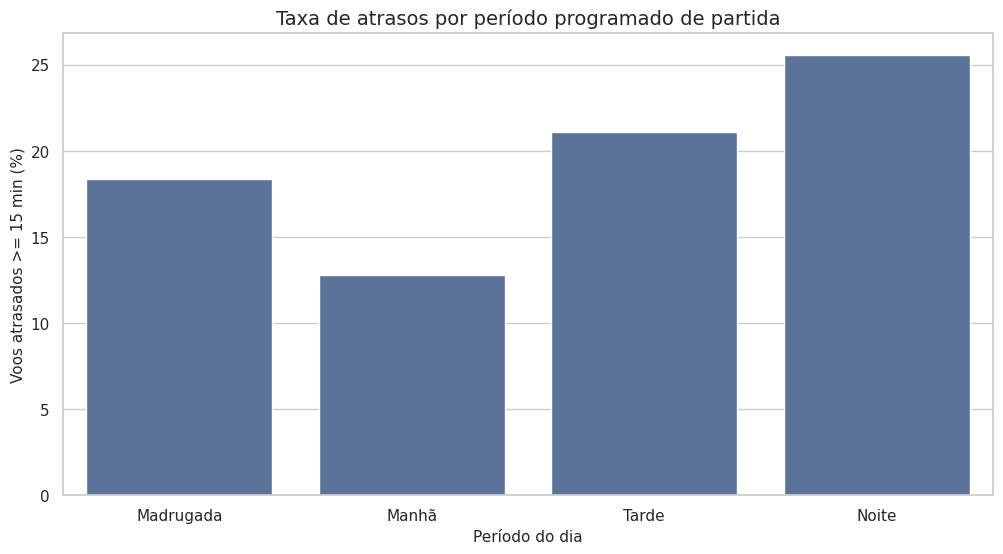

,DEPARTURE_PERIOD,total_voos,atraso_medio_chegada,taxa_atraso_15
0,Madrugada,65917,2.63,18.37
1,Manhã,2341610,0.00,12.80
2,Tarde,2102690,6.57,21.12
3,Noite,1203791,9.30,25.56


In [79]:
period_order = ["Madrugada", "Manhã", "Tarde", "Noite"]

period_delay = completed_flights.groupby("DEPARTURE_PERIOD").agg(
    total_voos=("ARRIVAL_DELAY", "size"),
    atraso_medio_chegada=("ARRIVAL_DELAY", "mean"),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reindex(period_order).reset_index()
period_delay["taxa_atraso_15"] *= 100

sns.barplot(data=period_delay, x="DEPARTURE_PERIOD", y="taxa_atraso_15", color="#5271a3")
plt.title("Taxa de atrasos por período programado de partida")
plt.xlabel("Período do dia")
plt.ylabel("Voos atrasados >= 15 min (%)")
plt.show()

period_delay

## 8. Companhias aéreas

**Comentário:** esta tabela compara companhias aéreas por volume, atraso médio e taxa de atraso, permitindo avaliar desempenho relativo.

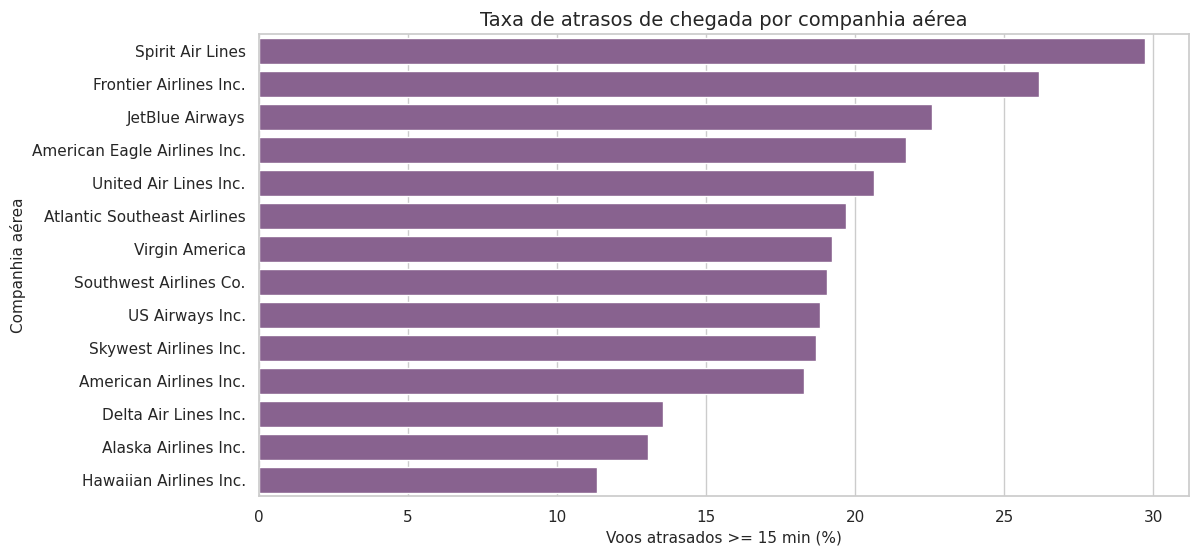

,AIRLINE,AIRLINE_NAME,total_voos,atraso_medio_chegada,mediana_atraso_chegada,taxa_atraso_15
8,NK,Spirit Air Lines,115193,14.47,0.00,29.71
5,F9,Frontier Airlines Inc.,90090,12.50,-1.00,26.16
2,B6,JetBlue Airways,262042,6.68,-5.00,22.58
7,MQ,American Eagle Airlines Inc.,278791,6.46,-6.00,21.72
10,UA,United Air Lines Inc.,507762,5.43,-6.00,20.62
4,EV,Atlantic Southeast Airlines,554752,6.59,-4.00,19.68
12,VX,Virgin America,61248,4.74,-3.00,19.23
13,WN,Southwest Airlines Co.,1242403,4.37,-4.00,19.05
11,US,US Airways Inc.,194223,3.71,-4.00,18.82
9,OO,Skywest Airlines Inc.,576814,5.85,-4.00,18.69


In [80]:
airline_delay = completed_flights.groupby(["AIRLINE", "AIRLINE_NAME"], observed=True).agg(
    total_voos=("ARRIVAL_DELAY", "size"),
    atraso_medio_chegada=("ARRIVAL_DELAY", "mean"),
    mediana_atraso_chegada=("ARRIVAL_DELAY", "median"),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reset_index()
airline_delay["taxa_atraso_15"] *= 100

airline_delay = airline_delay.sort_values("taxa_atraso_15", ascending=False)

sns.barplot(data=airline_delay, y="AIRLINE_NAME", x="taxa_atraso_15", color="#8d5a97")
plt.title("Taxa de atrasos de chegada por companhia aérea")
plt.xlabel("Voos atrasados >= 15 min (%)")
plt.ylabel("Companhia aérea")
plt.show()

airline_delay

## 9. Aeroportos e rotas críticas

**Comentário:** aplicamos um volume mínimo de voos para evitar destacar aeroportos com taxa alta baseada em poucas observações.

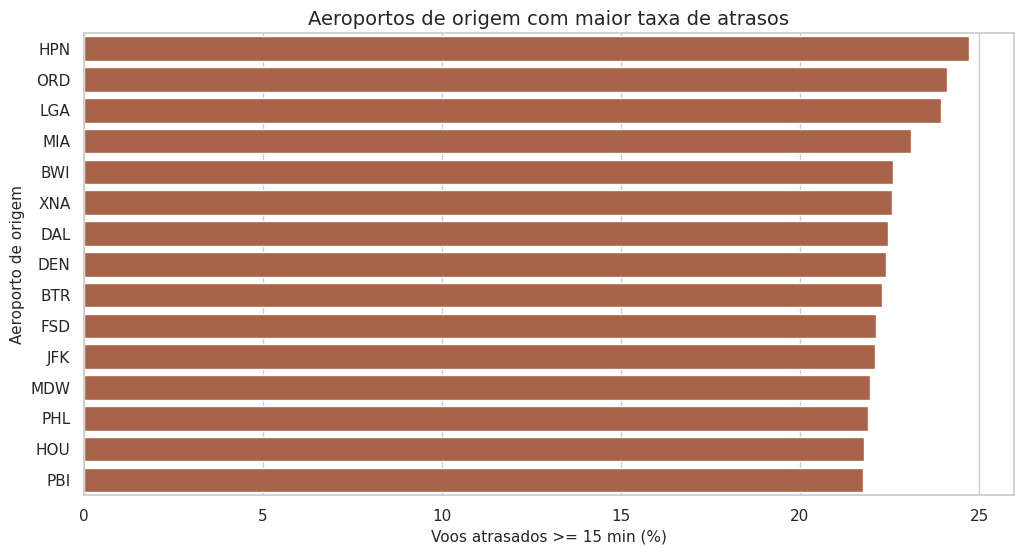

,ORIGIN_AIRPORT,ORIGIN_CITY,ORIGIN_STATE,total_voos,atraso_medio_chegada,taxa_atraso_15
144,HPN,White Plains,NY,7132,9.56,24.73
228,ORD,Chicago,IL,276554,8.60,24.10
182,LGA,New York,NY,94834,5.63,23.95
203,MIA,Miami,FL,68301,7.04,23.11
51,BWI,Baltimore,MD,84329,7.25,22.59
319,XNA,Fayetteville/Springdale/Rogers,AR,8963,11.23,22.58
81,DAL,Dallas,TX,58672,7.99,22.46
85,DEN,Denver,CO,193402,7.19,22.40
47,BTR,Baton Rouge,LA,6983,11.20,22.30
116,FSD,Sioux Falls,SD,5157,9.27,22.13


In [81]:
MIN_FLIGHTS_AIRPORT = 5_000

origin_delay = completed_flights.groupby(["ORIGIN_AIRPORT", "ORIGIN_CITY", "ORIGIN_STATE"], observed=True).agg(
    total_voos=("ARRIVAL_DELAY", "size"),
    atraso_medio_chegada=("ARRIVAL_DELAY", "mean"),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reset_index()
origin_delay["taxa_atraso_15"] *= 100

origin_delay_filtered = origin_delay.query("total_voos >= @MIN_FLIGHTS_AIRPORT").sort_values("taxa_atraso_15", ascending=False)

top_origins = origin_delay_filtered.head(15)
sns.barplot(data=top_origins, y="ORIGIN_AIRPORT", x="taxa_atraso_15", color="#b85c38")
plt.title("Aeroportos de origem com maior taxa de atrasos")
plt.xlabel("Voos atrasados >= 15 min (%)")
plt.ylabel("Aeroporto de origem")
plt.show()

top_origins

**Comentário:** a mesma lógica é aplicada às rotas: o filtro mínimo reduz conclusões instáveis causadas por amostras pequenas.

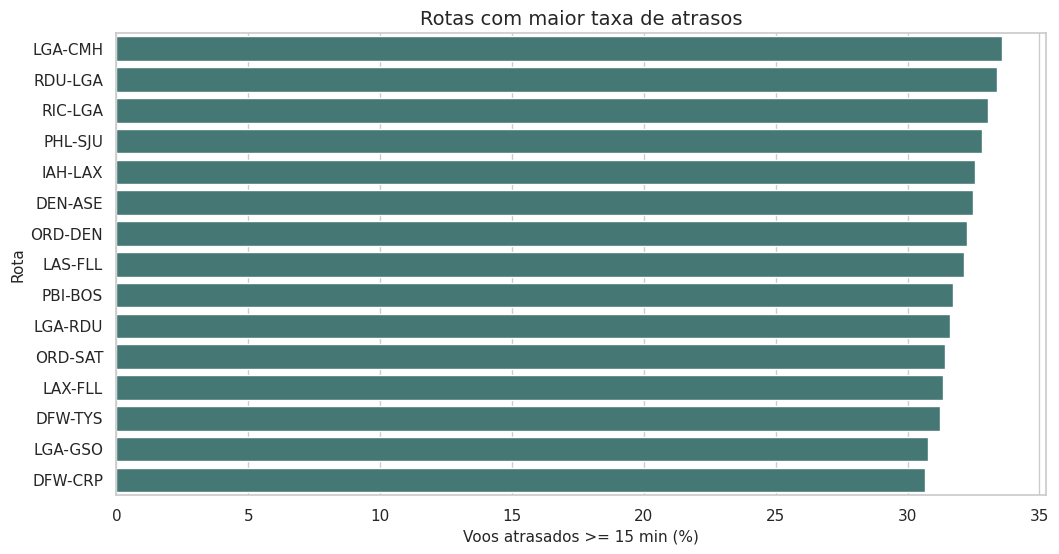

,ROUTE,total_voos,distancia_media,atraso_medio_chegada,taxa_atraso_15
6427,LGA-CMH,1316,479.00,12.38,33.59
7719,RDU-LGA,1677,431.00,17.20,33.39
7746,RIC-LGA,1283,292.00,17.89,33.05
7502,PHL-SJU,1024,1576.00,11.04,32.81
5964,IAH-LAX,4388,1379.00,16.74,32.54
4972,DEN-ASE,1019,125.00,15.62,32.48
7248,ORD-DEN,5517,888.00,18.14,32.26
6253,LAS-FLL,1024,2173.00,14.11,32.13
7392,PBI-BOS,1572,1197.00,15.74,31.74
6468,LGA-RDU,1775,431.00,13.08,31.61


In [82]:
MIN_FLIGHTS_ROUTE = 1_000

route_delay = completed_flights.groupby("ROUTE", observed=True).agg(
    total_voos=("ARRIVAL_DELAY", "size"),
    distancia_media=("DISTANCE", "mean"),
    atraso_medio_chegada=("ARRIVAL_DELAY", "mean"),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reset_index()
route_delay["taxa_atraso_15"] *= 100

route_delay_filtered = route_delay.query("total_voos >= @MIN_FLIGHTS_ROUTE").sort_values("taxa_atraso_15", ascending=False)

sns.barplot(data=route_delay_filtered.head(15), y="ROUTE", x="taxa_atraso_15", color="#3d7f7b")
plt.title("Rotas com maior taxa de atrasos")
plt.xlabel("Voos atrasados >= 15 min (%)")
plt.ylabel("Rota")
plt.show()

route_delay_filtered.head(15)

## 10. Cancelamentos e motivos

**Comentário:** os motivos de cancelamento são codificados no CSV; esta célula traduz os códigos para descrições mais legíveis.

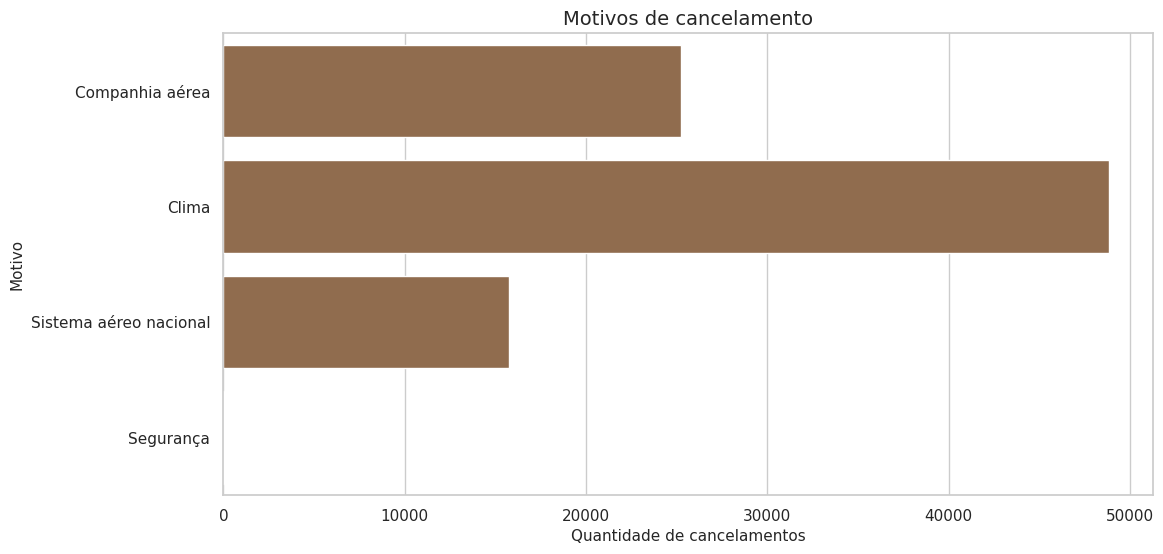

,CANCELLATION_REASON_DESC,total_cancelamentos
0,Clima,48851
1,Companhia aérea,25262
2,Sistema aéreo nacional,15749
3,Segurança,22


In [83]:
cancel_reason_map = {
    "A": "Companhia aérea",
    "B": "Clima",
    "C": "Sistema aéreo nacional",
    "D": "Segurança",
}

cancelled = flights_eda.query("CANCELLED == 1").copy()
cancelled["CANCELLATION_REASON_DESC"] = cancelled["CANCELLATION_REASON"].map(cancel_reason_map)

cancel_summary = cancelled.groupby("CANCELLATION_REASON_DESC").agg(
    total_cancelamentos=("CANCELLED", "size"),
).sort_values("total_cancelamentos", ascending=False).reset_index()

sns.barplot(data=cancel_summary, x="total_cancelamentos", y="CANCELLATION_REASON_DESC", color="#9b6b43")
plt.title("Motivos de cancelamento")
plt.xlabel("Quantidade de cancelamentos")
plt.ylabel("Motivo")
plt.show()

cancel_summary

## 10.1 Taxas de cancelamento

Além do motivo do cancelamento, a flag `CANCELLED` permite medir quando os cancelamentos se concentram. Essa análise deve ficar separada da análise de atraso de chegada, porque voos cancelados não têm chegada real.

**Comentário:** cancelamentos e desvios são analisados separadamente dos atrasos, pois representam status operacionais diferentes.

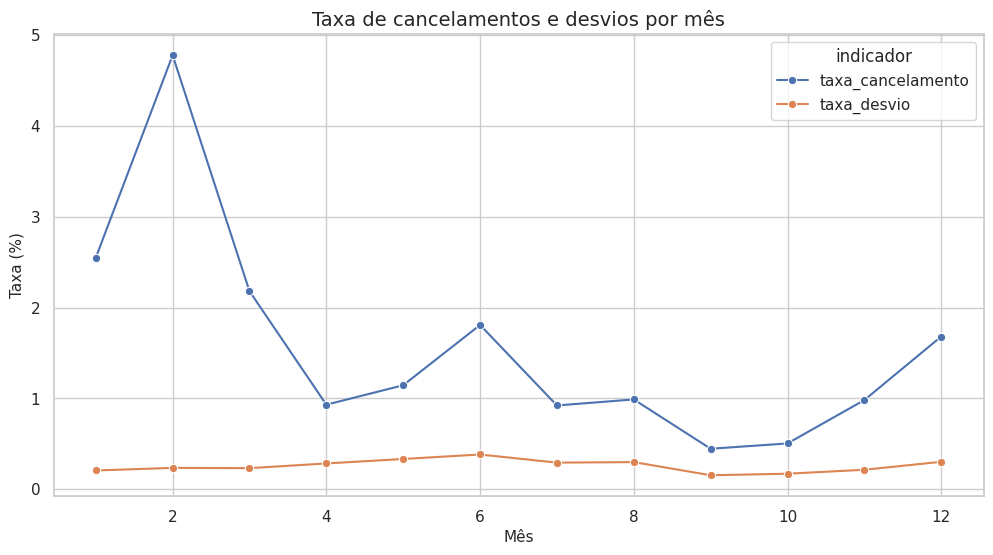

,MONTH,total_voos,taxa_cancelamento,taxa_desvio
0,1,469968,2.55,0.21
1,2,429191,4.78,0.24
2,3,504312,2.18,0.23
3,4,485151,0.93,0.28
4,5,496993,1.15,0.33
5,6,503897,1.81,0.38
6,7,520718,0.92,0.29
7,8,510536,0.99,0.30
8,9,464946,0.45,0.15
9,10,486165,0.50,0.17


In [84]:
cancel_rate_month = flights_eda.groupby("MONTH").agg(
    total_voos=("CANCELLED", "size"),
    taxa_cancelamento=("CANCELLED", "mean"),
    taxa_desvio=("DIVERTED", "mean"),
).reset_index()
cancel_rate_month[["taxa_cancelamento", "taxa_desvio"]] *= 100

cancel_rate_month_melted = cancel_rate_month.melt(
    id_vars="MONTH",
    value_vars=["taxa_cancelamento", "taxa_desvio"],
    var_name="indicador",
    value_name="taxa_%",
)

sns.lineplot(data=cancel_rate_month_melted, x="MONTH", y="taxa_%", hue="indicador", marker="o")
plt.title("Taxa de cancelamentos e desvios por mês")
plt.xlabel("Mês")
plt.ylabel("Taxa (%)")
plt.show()

cancel_rate_month

## 11. Composição dos atrasos

As colunas abaixo indicam a atribuição do atraso em minutos por categoria. Para esta análise, valores nulos foram tratados como `0`, pois representam ausência de atraso atribuído naquela categoria.

**Comentário:** para analisar a composição dos atrasos, os nulos das causas são tratados como zero, pois indicam ausência de minutos atribuídos àquela causa.

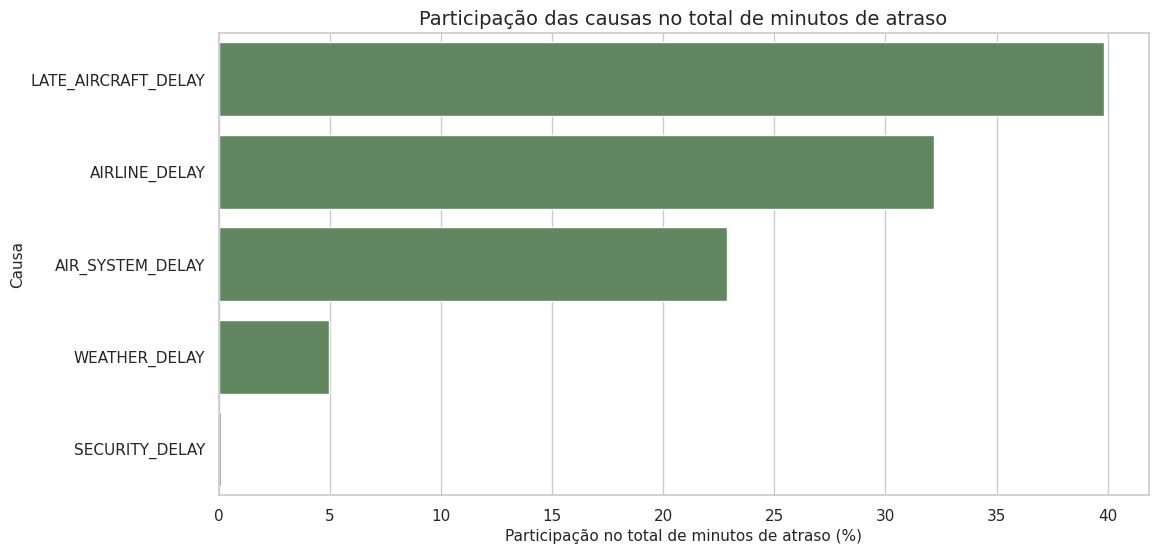

,causa,minutos_totais,participacao_%
0,LATE_AIRCRAFT_DELAY,24961932.00,39.84
1,AIRLINE_DELAY,20172956.00,32.20
2,AIR_SYSTEM_DELAY,14335762.00,22.88
3,WEATHER_DELAY,3100233.00,4.95
4,SECURITY_DELAY,80985.00,0.13


In [85]:
treated_delay_reason_cols = [f"{col}_TREATED" for col in delay_reason_cols]

delay_reason_summary = delayed_arrivals[treated_delay_reason_cols].sum().sort_values(ascending=False).rename_axis("causa").reset_index(name="minutos_totais")
delay_reason_summary["causa"] = delay_reason_summary["causa"].str.replace("_TREATED", "", regex=False)
delay_reason_summary["participacao_%"] = delay_reason_summary["minutos_totais"] / delay_reason_summary["minutos_totais"].sum() * 100

sns.barplot(data=delay_reason_summary, y="causa", x="participacao_%", color="#5b8c5a")
plt.title("Participação das causas no total de minutos de atraso")
plt.xlabel("Participação no total de minutos de atraso (%)")
plt.ylabel("Causa")
plt.show()

delay_reason_summary

## 11.1 Preenchimento das causas de atraso

As causas de atraso estão em minutos e só são informativas quando há atraso registrado. Por isso, avaliamos a taxa de preenchimento separando voos atrasados e não atrasados.

**Comentário:** esta tabela verifica quando as causas de atraso estão preenchidas e qual a média de minutos quando há registro, evitando interpretar nulos de forma errada.

In [86]:
cause_fill_rate = []
for col in delay_reason_cols:
    cause_fill_rate.append({
        "causa": col,
        "preenchimento_todos_%": flights_eda[col].notna().mean() * 100,
        "preenchimento_voos_atrasados_%": delayed_arrivals[col].notna().mean() * 100,
        "media_minutos_quando_preenchido": delayed_arrivals[col].dropna().mean(),
    })

pd.DataFrame(cause_fill_rate).sort_values("preenchimento_voos_atrasados_%", ascending=False)

,causa,preenchimento_todos_%,preenchimento_voos_atrasados_%,media_minutos_quando_preenchido
0,AIR_SYSTEM_DELAY,18.28,100.00,13.48
1,SECURITY_DELAY,18.28,100.00,0.08
2,AIRLINE_DELAY,18.28,100.00,18.97
3,LATE_AIRCRAFT_DELAY,18.28,100.00,23.47
4,WEATHER_DELAY,18.28,100.00,2.92


## 12. Mapa de calor temporal

Este gráfico ajuda a identificar combinações críticas entre mês e dia da semana.

**Comentário:** o mapa de calor combina mês e dia da semana para revelar períodos críticos que podem não aparecer em análises isoladas.

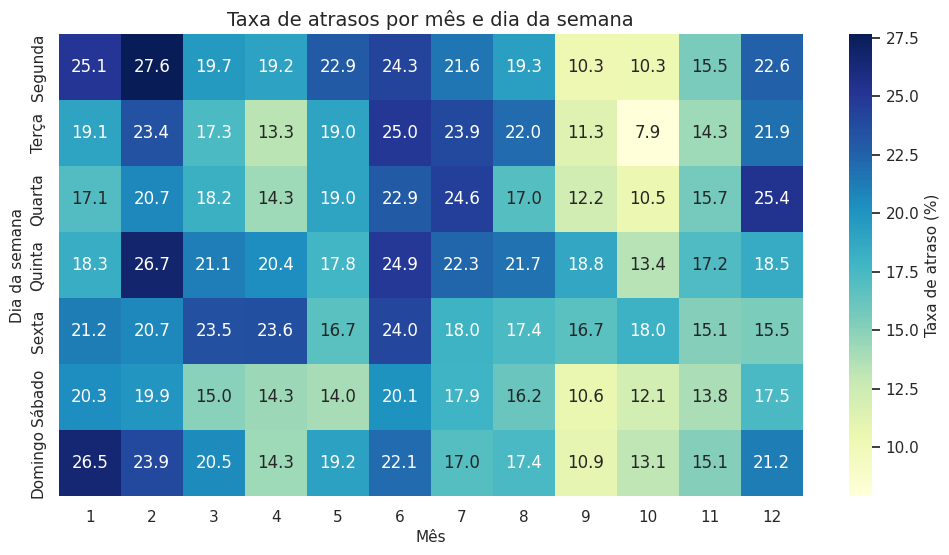

In [87]:
heatmap_data = completed_flights.pivot_table(
    index="DAY_OF_WEEK_NAME",
    columns="MONTH",
    values="IS_DELAYED_ARRIVAL_15",
    aggfunc="mean",
).reindex(weekday_order) * 100

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Taxa de atraso (%)"})
plt.title("Taxa de atrasos por mês e dia da semana")
plt.xlabel("Mês")
plt.ylabel("Dia da semana")
plt.show()

## 12.1 Sazonalidade em feriados

**Comentário:** esta análise verifica se feriados federais dos EUA em 2015, e a janela de três dias antes/depois deles, concentram mais atrasos. A janela é importante porque o tráfego aéreo costuma aumentar nos dias próximos ao feriado, não apenas no dia exato.

In [ ]:
us_federal_holidays_2015 = pd.to_datetime([
    "2015-01-01",  # New Year's Day
    "2015-01-19",  # Martin Luther King Jr. Day
    "2015-02-16",  # Presidents' Day
    "2015-05-25",  # Memorial Day
    "2015-07-03",  # Independence Day observed
    "2015-07-04",  # Independence Day
    "2015-09-07",  # Labor Day
    "2015-10-12",  # Columbus Day
    "2015-11-11",  # Veterans Day
    "2015-11-26",  # Thanksgiving Day
    "2015-12-25",  # Christmas Day
])

completed_flights["IS_US_FEDERAL_HOLIDAY"] = completed_flights["FLIGHT_DATE"].isin(us_federal_holidays_2015)

holiday_window_masks = [
    completed_flights["FLIGHT_DATE"].between(
        holiday - pd.Timedelta(days=3),
        holiday + pd.Timedelta(days=3),
    )
    for holiday in us_federal_holidays_2015
]
completed_flights["IS_HOLIDAY_WINDOW_3D"] = np.logical_or.reduce(holiday_window_masks)

holiday_summary = completed_flights.groupby("IS_US_FEDERAL_HOLIDAY").agg(
    total_voos=("ARRIVAL_DELAY", "size"),
    atraso_medio_chegada=("ARRIVAL_DELAY", "mean"),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reset_index()
holiday_summary["taxa_atraso_15"] *= 100
holiday_summary["tipo_periodo"] = np.where(
    holiday_summary["IS_US_FEDERAL_HOLIDAY"],
    "Feriado federal",
    "Demais dias",
)

holiday_window_summary = completed_flights.groupby("IS_HOLIDAY_WINDOW_3D").agg(
    total_voos=("ARRIVAL_DELAY", "size"),
    atraso_medio_chegada=("ARRIVAL_DELAY", "mean"),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reset_index()
holiday_window_summary["taxa_atraso_15"] *= 100
holiday_window_summary["tipo_periodo"] = np.where(
    holiday_window_summary["IS_HOLIDAY_WINDOW_3D"],
    "Janela de feriado (+/- 3 dias)",
    "Fora da janela",
)

display(holiday_summary[["tipo_periodo", "total_voos", "atraso_medio_chegada", "taxa_atraso_15"]])
display(holiday_window_summary[["tipo_periodo", "total_voos", "atraso_medio_chegada", "taxa_atraso_15"]])

**Comentário:** a tabela abaixo destaca os dias mais críticos dentro das janelas de feriado. Ela ajuda a diferenciar o comportamento médio da janela de alguns picos específicos de atraso.

In [ ]:
holiday_window_daily = completed_flights.query("IS_HOLIDAY_WINDOW_3D").groupby("FLIGHT_DATE").agg(
    total_voos=("ARRIVAL_DELAY", "size"),
    atraso_medio_chegada=("ARRIVAL_DELAY", "mean"),
    taxa_atraso_15=("IS_DELAYED_ARRIVAL_15", "mean"),
).reset_index()
holiday_window_daily["taxa_atraso_15"] *= 100

worst_holiday_window_days = holiday_window_daily.sort_values("taxa_atraso_15", ascending=False).head(10)

sns.barplot(data=worst_holiday_window_days, y="FLIGHT_DATE", x="taxa_atraso_15", color="#b85c38")
plt.title("Dias mais críticos dentro da janela de feriados")
plt.xlabel("Voos atrasados >= 15 min (%)")
plt.ylabel("Data")
plt.show()

worst_holiday_window_days

## 13. Principais achados da EDA

Com base na execução da EDA sobre a base completa de 2015, os principais achados são:

- A base possui **5.819.079 voos**, dos quais **5.714.008 foram concluídos**. A taxa de cancelamento é de aproximadamente **1,54%** e a taxa de desvios é de **0,26%**.
- Entre os voos concluídos, **18,61% chegaram com atraso de 15 minutos ou mais**. O atraso médio de chegada foi de **4,41 minutos**, mas a mediana foi de **-5 minutos**, indicando que mais da metade dos voos chegou adiantada ou no horário. A cauda é relevante: o p95 do atraso de chegada foi **66 minutos** e o p99 foi **167 minutos**.
- Existe **sazonalidade mensal**. Os meses mais críticos foram **junho (23,48%)**, **fevereiro (23,35%)**, **janeiro (21,00%)**, **julho (20,92%)** e **dezembro (20,60%)**. Os melhores meses foram **outubro (12,44%)** e **setembro (13,00%)**.
- Existe **sazonalidade por horário**. Voos programados para a **noite** tiveram a maior taxa de atraso (**25,56%**), seguidos por **tarde (21,12%)**, **madrugada (18,37%)** e **manhã (12,80%)**. Isso sugere acúmulo de atrasos ao longo do dia operacional.
- Por dia da semana, **quinta-feira (20,01%)**, **segunda-feira (19,75%)** e **sexta-feira (19,20%)** concentraram as maiores taxas de atraso. **Sábado** foi o dia menos crítico, com **15,99%**.
- Em feriados federais dos EUA, a taxa média de atraso foi menor (**15,55%**) do que nos demais dias (**18,70%**). Porém, considerando uma janela de **três dias antes/depois dos feriados**, a taxa sobe para **19,18%**, contra **18,48%** fora da janela. Ou seja, o impacto parece estar mais nos dias de deslocamento ao redor do feriado do que no dia exato.
- Alguns dias próximos a feriados foram extremamente críticos, como **2015-01-04 (49,30%)**, **2015-01-03 (45,22%)**, **2015-12-27 (39,84%)**, **2015-12-23 (37,72%)** e **2015-12-28 (36,38%)**.
- As companhias com maiores taxas de atraso foram **Spirit (NK, 29,71%)**, **Frontier (F9, 26,16%)**, **JetBlue (B6, 22,58%)**, **American Eagle (MQ, 21,72%)** e **United (UA, 20,62%)**. As menores taxas apareceram em **Hawaiian (HA, 11,33%)**, **Alaska (AS, 13,04%)** e **Delta (DL, 13,56%)**.
- Entre aeroportos de origem com pelo menos 5.000 voos, os mais críticos foram **HPN (24,73%)**, **ORD (24,10%)**, **LGA (23,95%)**, **MIA (23,11%)** e **BWI (22,59%)**. Entre os aeroportos de maior volume, **ORD**, **DEN**, **DFW**, **LAX**, **SFO** e **IAH** também merecem atenção por combinarem grande operação com taxas relevantes de atraso.
- Entre rotas com pelo menos 1.000 voos, as maiores taxas de atraso apareceram em **LGA-CMH (33,59%)**, **RDU-LGA (33,39%)**, **RIC-LGA (33,05%)**, **PHL-SJU (32,81%)** e **IAH-LAX (32,54%)**.
- As causas com maior participação no total de minutos de atraso foram **chegada tardia da aeronave (39,84%)**, **atraso atribuível à companhia aérea (32,20%)**, **sistema aéreo/controle de tráfego (22,88%)**, **clima (4,95%)** e **segurança (0,13%)**.
- Os cancelamentos foram causados principalmente por **clima (48.851 ocorrências)**, depois **companhia aérea (25.262)**, **sistema aéreo nacional (15.749)** e **segurança (22)**.
- As validações de consistência indicaram boa qualidade nos campos operacionais: `ELAPSED_TIME` fecha com `AIR_TIME + TAXI_OUT + TAXI_IN`, e a reconciliação entre atraso de partida, tempo real/programado e atraso de chegada ficou praticamente zerada.

Resposta às perguntas-guia do desafio:

- **Quais aeroportos são mais críticos em relação a atrasos?** Sim, a EDA identifica aeroportos críticos por taxa e volume, com destaque para HPN, ORD, LGA, MIA, BWI e DEN.
- **Que características aumentam a chance de atraso?** A EDA aponta associações com período da noite, meses como junho/fevereiro/dezembro, determinados aeroportos, rotas e companhias. Ainda não é causalidade; a modelagem supervisionada ajudará a quantificar melhor esse efeito.
- **Os atrasos são mais comuns em certos dias da semana ou horários?** Sim. Noite e tarde são mais críticas, e quinta, segunda e sexta têm taxas maiores que sábado.
- **Existe sazonalidade por mês ou feriados?** Sim para mês e horário. Em feriados exatos a taxa não aumenta, mas há leve aumento na janela de três dias ao redor dos feriados e picos fortes em datas específicas próximas a Ano Novo e Natal.
- **É possível agrupar aeroportos com perfis semelhantes?** Ainda não nesta EDA. Temos variáveis candidatas para clusterização, como taxa de atraso, atraso médio, volume, taxiamento e composição de causas, mas a clusterização deve entrar na etapa não supervisionada.
- **Até que ponto conseguimos prever atrasos com histórico e contexto?** Ainda não foi respondido nesta etapa. A EDA mostra sinais preditivos promissores, mas a resposta depende da etapa de modelagem supervisionada e avaliação com métricas adequadas.

## 14. Próximos passos

- Criar uma base analítica com variáveis selecionadas para modelagem.
- Definir o alvo supervisionado: classificação de atraso `>= 15 min` ou regressão do tempo de atraso.
- Comparar pelo menos dois algoritmos supervisionados com métricas adequadas.
- Aplicar uma abordagem não supervisionada, como clusterização de aeroportos, rotas ou companhias.
- Consolidar conclusões, limitações e propostas de melhoria para a apresentação final.